In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ["MPLCONFIGDIR"] = f"/tmp/{os.environ['USER']}_matplotlib_cache"

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import healpy as hp
from cogwheel import gw_utils, utils, gw_plotting, plotting
from cogwheel.likelihood.marginalization.coherent_score_lensing import bootstrap_bayes_factors

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
import helpers

warnings.simplefilter("ignore", RuntimeWarning)

#### compute $R_{md}$ from the injections: is this a well-measured quantity?

In [4]:
def Rd(mu, Fplus, Fcross):
    return (1 + mu**2) / 2 * Fplus - 1j * mu * Fcross

def get_Rmd(m, mu, Fplus, Fcross, phi, D):
    siniota = np.sqrt(1 - mu**2)    # identity: cos^2 iota + sin^2 iota = 1
    return Rd(mu, Fplus, Fcross) * np.exp(1j * m * phi) * siniota**(m-2) / D

In [7]:
# load the injection posteriors
approximant = 'IMRPhenomXPHM'
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/IntrinsicLVCPrior'
seed = 12

idx = 1
# load this sample
eventname = f'GW{seed}_{idx}'
eventdir = os.path.join(resdir, eventname)
event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(eventdir, eventname)

loaded posterior samples for GW12_1 run 0


In [10]:
# calculate Rmd
m = 2
# from the posterior samples
mu = np.cos(samples['iota'])
fp, fc = np.array([
    gw_utils.fplus_fcross(event_data.detector_names, ra, dec, psi, event_data.tgps).T \
        for (ra, dec, psi) in zip(samples['ra'], samples['dec'], samples['psi'])
]).T
Rmds = np.empty(fp.shape, dtype=complex)
Rmds_dic = {}
for i, (det_name, fpd, fcd) in enumerate(zip(event_data.detector_names, fp, fc)):
    Rmd = get_Rmd(m, mu, fpd, fcd, samples['phi_ref'], samples['d_luminosity'])
    Rmds[i] = Rmd
    Rmds_dic[det_name +'_real'] = np.real(Rmd)
    Rmds_dic[det_name +'_imag'] = np.imag(Rmd)
# multiply the Rmd of the lensed samples by i
lensed = samples['lensed']
Rmds[:,lensed] *= 1j
# turn this dictionary into a dataframe for plotting
Rmds_df = pd.DataFrame.from_dict(Rmds_dic)
# from the injection
Rmds_inj = {}
inj_par_dic = event_data.injection['par_dic']
fp_inj, fc_inj = gw_utils.fplus_fcross(event_data.detector_names, inj_par_dic['ra'], inj_par_dic['dec'], inj_par_dic['psi'], event_data.tgps)
# Rmds_inj = np.empty()
for (det_name, fpd, fcd) in zip(event_data.detector_names, fp_inj, fc_inj):
    Rmd_inj = get_Rmd(m, np.cos(inj_par_dic['iota']), fpd, fcd, inj_par_dic['phi_ref'], inj_par_dic['d_luminosity'])
    Rmds_inj[det_name +'_real'] = np.real(Rmd_inj)
    Rmds_inj[det_name +'_imag'] = np.imag(Rmd_inj)

Text(0.5, 0.98, 'GW12_1: $R_{md}\\equiv R_d e^{im\\phi}\\sin^{(m-2)}\\iota / D_L$ ($m=2$)')

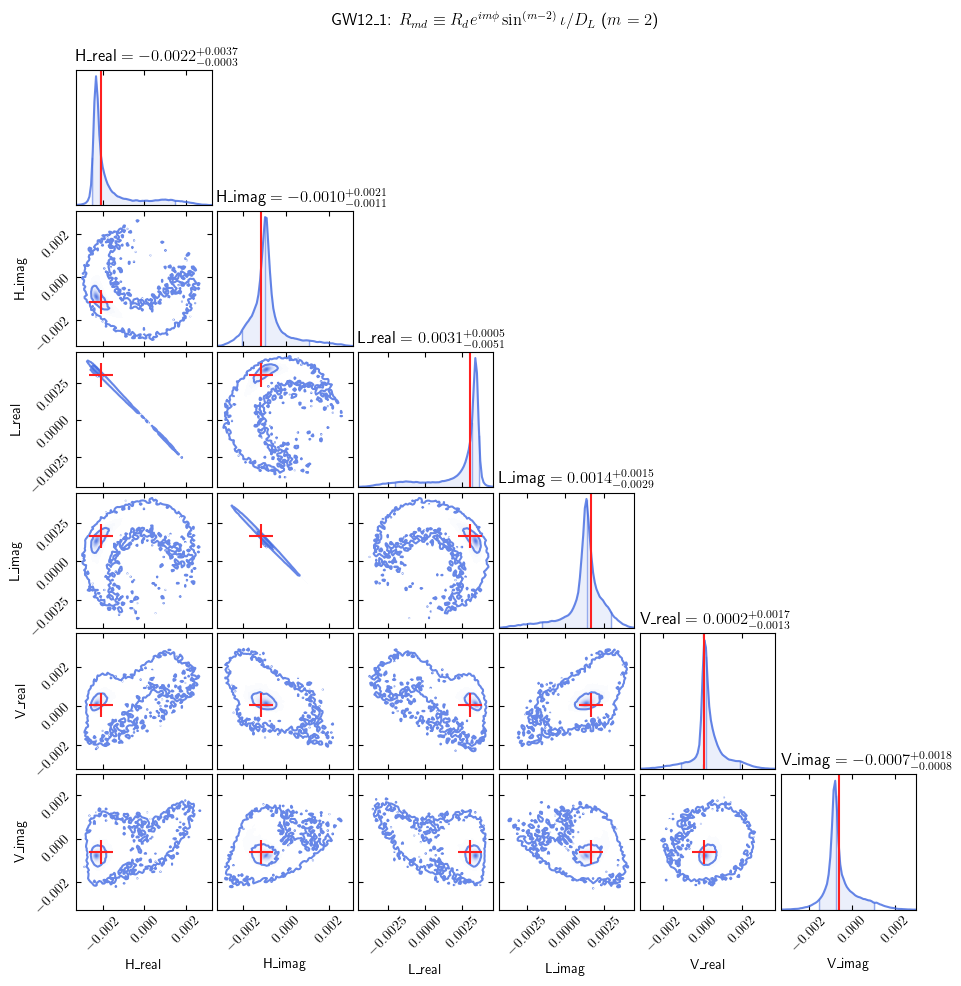

In [11]:
# corner plot
corner_plot_kwargs = dict(tail_probability=1e-3, color_2d='royalblue',
    kwargs_1d=dict(color='royalblue', alpha=0.8), contour_kwargs=dict(alpha=0.8))

cp = gw_plotting.CornerPlot(Rmds_df, **corner_plot_kwargs)
cp.plot()
# injected parameters
cp.scatter_points(Rmds_inj, colors=['#FF2020'], s=300,
                                    zorder=2, marker='+', adjust_lims=True)
cp.fig.suptitle(f'{eventname}: 'r'$R_{md}\equiv R_d e^{im\phi}\sin^{(m-2)}\iota / D_L$ ($m=2$)')

In [12]:
Rmds_i_dic = {}
for i, (det_name, Rmd) in enumerate(zip(event_data.detector_names, Rmds)):
    Rmds_i_dic[det_name +'_real'] = np.real(Rmd)
    Rmds_i_dic[det_name +'_imag'] = np.imag(Rmd)
Rmds_i_df = pd.DataFrame.from_dict(Rmds_i_dic)

Text(0.5, 0.98, 'GW12_1: $R_{md}\\equiv R_d e^{im\\phi}\\sin^{(m-2)}\\iota / D_L$ ($m=2$)')

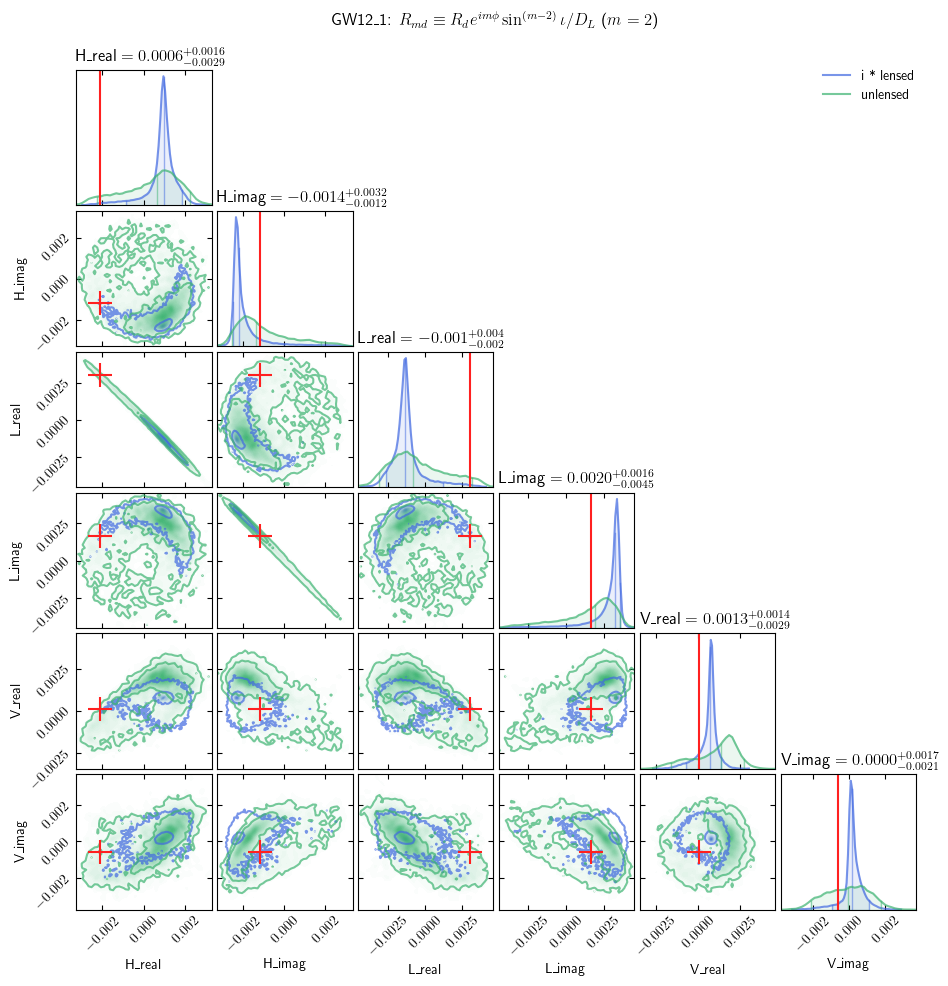

In [13]:
# split into lensed and unlensed?
c1, c2 = 'royalblue', 'mediumseagreen'
plotstyles = [
    plotting.PlotStyle(color_2d=c1, contour_kwargs=dict(alpha=0.7), kwargs_1d=dict(color=c1, alpha=0.7), tail_probability=1e-3),
    plotting.PlotStyle(color_2d=c2, contour_kwargs=dict(alpha=0.7), kwargs_1d=dict(color=c2, alpha=0.7), tail_probability=1e-3)
]
cp = gw_plotting.MultiCornerPlot({'i * lensed' : Rmds_i_df[lensed], 'unlensed' : Rmds_i_df[~lensed]},
                                 plotstyles=plotstyles)
cp.plot()
cp.scatter_points(Rmds_inj, colors=['#FF2020'], s=300,
                                    zorder=2, marker='+', adjust_lims=True)
fig = cp.corner_plots[0].fig
fig.suptitle(f'{eventname}: 'r'$R_{md}\equiv R_d e^{im\phi}\sin^{(m-2)}\iota / D_L$ ($m=2$)')

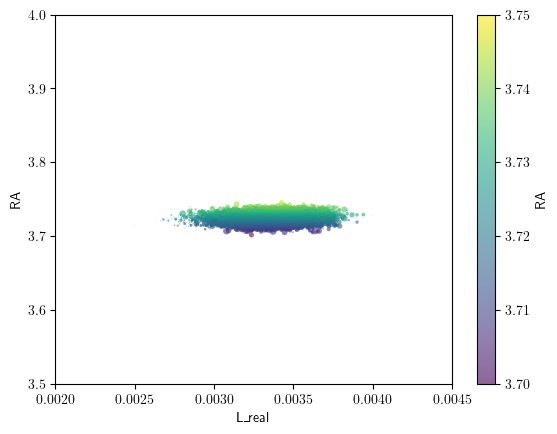

In [29]:
plt.scatter(Rmds_df.loc[lensed, 'L_real'], samples[lensed]['ra'],
            c=samples[lensed]['ra'], s=samples[lensed]['weights']/samples['weights'].max() *40, alpha=0.6, lw=0,
            vmin=3.7, vmax=3.75)
plt.xlim(.002,.0045)
plt.ylim(3.5,4)
plt.xlabel('L_real')
plt.ylabel('RA')
plt.colorbar(label='RA')

In [ ]:
# load the injection posteriors
approximant = 'IMRPhenomXPHM'
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/IntrinsicLVCPrior'
seed = 12
nevents = 100
idx_existing = []
idx_to_run = []

Rmd = {}

for idx in range(nevents):
    # load this sample
    eventname = f'GW{seed}_{idx}'
    eventdir = os.path.join(resdir, eventname)
    try:
        event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(eventdir, eventname)
        idx_existing.append(idx)
    except FileNotFoundError:
        print(f"no samples for idx {idx}. continuing")
        idx_to_run.append(idx)
        continue

    # calculate Rmd from the posterior samples
    mu = np.cos(samples['iota'])
    fp, fc = np.array([
        gw_utils.fplus_fcross()
    ])

    # add derived quantities to the injection dictionary
    injection_dict = event_data.get_init_dict()['injection']
    injected_par_dict = injection_dict['par_dic']
    helpers.add_derived_quantities_injection(injected_par_dict)
    # add cos iota
    injected_par_dict['cosiota'] = np.cos(injected_par_dict['iota'])

    # optimal SNR: inner product from the injection
    h_h[idx] = np.sum(injection_dict['h_h'])

    # Bayes factor
    lnBayes_fn = os.path.join(samples_dir, 'lnBayes.npy')
    try:
        lnBayes[idx] = np.load(lnBayes_fn)
    except FileNotFoundError:
        bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
        # log these
        lnBayes_factors = np.log(bayes_factors)
        # get the median and standard deviation
        lnBayes[idx] = (np.median(lnBayes_factors), np.std(lnBayes_factors))
        np.save(lnBayes_fn, lnBayes[idx])

    # median from the posterior
    for par_id, injected_value in injected_par_dict.items():
        median_post = utils.quantile(samples[par_id], 0.5, weights=samples['weights'])
        try:
            params[par_id][idx] = (injected_value, median_post)
        except KeyError:    # if the dictionary doesn't exist yet
            params[par_id] = {}
            params[par_id][idx] = (injected_value, median_post)

In [5]:
# random values
mu = 0.5
m = 2
phi = 0.5
D = 500 # Mpc
# get the antenna response functions
ra, dec = 0.5, 0.5
psi = 0.
tgps = 0.
fp, fc = gw_utils.fplus_fcross('H', ra, dec, psi, tgps)

Rmd = get_Rmd(m, mu, fp, fc, phi, D)

In [6]:
Rmd

array([-0.00031317-0.00091683j])